# DSCI 631 Final Project EDA

Group 2\
Leland Weeks\
lhw22@drexel.edu\
June 2026

### Board Game Ratings Using BoardGameGeek Data

**Source:** https://www.kaggle.com/datasets/threnjen/board-games-database-from-boardgamegeek

This notebook performs full exploratory data analysis in support of three research questions:
1. What games are overrated and underrated?
2. What features make a boardgame enjoyable?
3. What level of complexity makes a game successful within a genre?

### Files

| File | Description | Usage | 
|------|-------------|-------|
| `games.csv` | Core file containing all primary features and target variables | Needed to answer all 3 questions
| `mechanics.csv` | Game mechanics like `Dice Rolling`, `Cooperative Game`) | Feature set for Q2 |
| `themes.csv` | Genres like `Fantasy`, `Science Fiction`, `Horror` | Feature set for Q2 |
| `subcategories.csv` | Game categories like `Card Game`, `Puzzle` | Feature set for Q2 |

### Key Features

- **Numeric features:** `GameWeight`, `MinPlayers`, `MaxPlayers`, `MfgPlayTime`, `NumOwned`, `NumWant`, `NumExpansions`, `YearPublished`, etc.
- **Binary features:** `IsReimplementation`, `Kickstarted`, subcategories `Strategy`, `Thematic`, etc.

In [4]:
import sys
import os
sys.path.append(os.path.join(os.path.dirname(''), '../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data import load_data, merge_data

In [5]:
dfs = load_data()

print('Files loaded:')
for key, df in dfs.items():
    print(f'  {key}: {df.shape}')

df = merge_data(dfs)

print('Merged into one dataframe:')
print(f'  {df.shape}')

Files loaded:
  games: (21925, 48)
  mechanics: (21925, 158)
  themes: (21925, 218)
  subcategories: (21925, 11)
Merged into one dataframe:
  (21925, 432)


In [90]:
NUMERIC_FEATURES = [
    'AvgRating', 'GameWeight', 'NumOwned', 'NumWant',
    'MinPlayers', 'MaxPlayers', 'MfgPlaytime',
    'NumExpansions', 'YearPublished'
]

display(df[NUMERIC_FEATURES].describe().round(2))

,AvgRating,GameWeight,NumOwned,NumWant,MinPlayers,MaxPlayers,MfgPlaytime,NumExpansions,YearPublished
count,21925.00,21925.00,21925.00,21925.00,21925.00,21925.00,21925.00,21925.00,21925.00
mean,6.42,1.98,1467.85,41.69,2.01,5.71,90.51,1.38,1985.49
std,0.93,0.85,5294.12,117.26,0.69,15.01,529.66,7.70,212.49
min,1.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-3500.00
25%,5.84,1.33,150.00,3.00,2.00,4.00,25.00,0.00,2001.00
50%,6.45,1.97,320.00,9.00,2.00,4.00,45.00,0.00,2011.00
75%,7.05,2.53,899.00,28.00,2.00,6.00,90.00,1.00,2017.00
max,9.91,5.00,166497.00,2031.00,10.00,999.00,60000.00,525.00,2021.00


In [47]:
# missing nulls in order of most missing
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print('Missing Values:')
print(f'{nulls}')

Missing Values:
Family          15262
LanguageEase     5891
ComAgeRec        5530
ImagePath          17
Description         1
dtype: int64


Mean:  6.42
Std:   0.93
Skew: -0.31
Range: 1.04 - 9.91


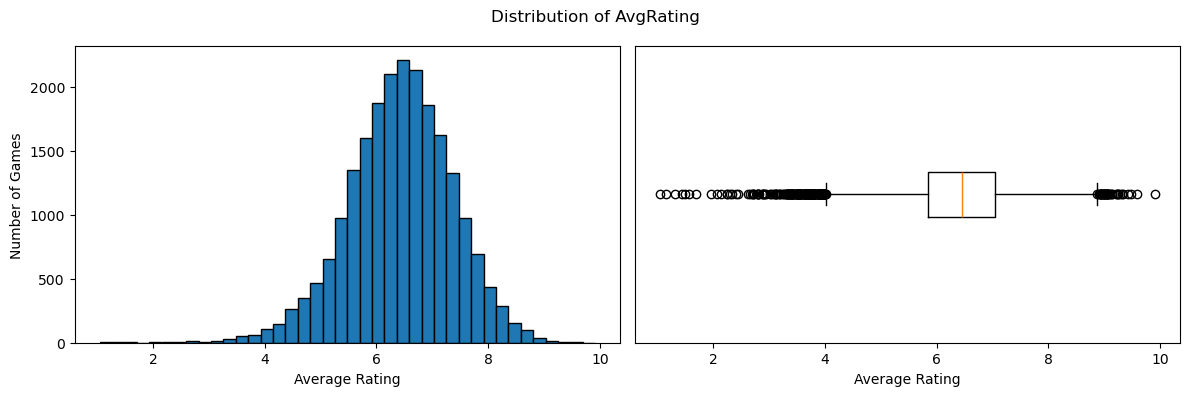

In [53]:
# target variable 
data = df['AvgRating'].dropna()

print(f'Mean:  {data.mean():.2f}')
print(f'Std:   {data.std():.2f}')
print(f'Skew: {data.skew():.2f}')
print(f'Range: {data.min():.2f} - {data.max():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribution of AvgRating')
axes[0].hist(data, bins=40, edgecolor='black')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Number of Games')
axes[1].boxplot(data, vert=False)
axes[1].set_xlabel('Average Rating')
axes[1].set_yticks([])
plt.tight_layout()
plt.show()
plt.close()

Skew:  12.52
Log1p:  0.76


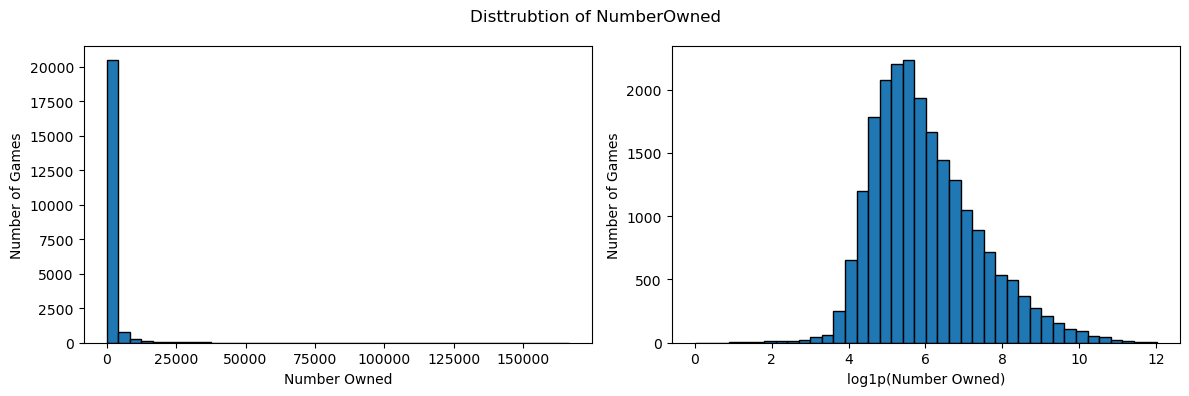

In [59]:
data = df['NumOwned'].dropna()
data_log = np.log1p(data)

print(f'Skew:  {data.skew():.2f}')
print(f'Log1p:  {data_log.skew():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data, bins=40, edgecolor='black')
fig.suptitle('Disttrubtion of NumberOwned')
axes[0].set_xlabel('Number Owned')
axes[0].set_ylabel('Number of Games')
axes[1].hist(data_log, bins=40, edgecolor='black')
axes[1].set_xlabel('log1p(Number Owned)')
axes[1].set_ylabel('Number of Games')
plt.tight_layout()
plt.show()
plt.close()


Mean: 1.98
Std:  0.85
Skew: 0.40


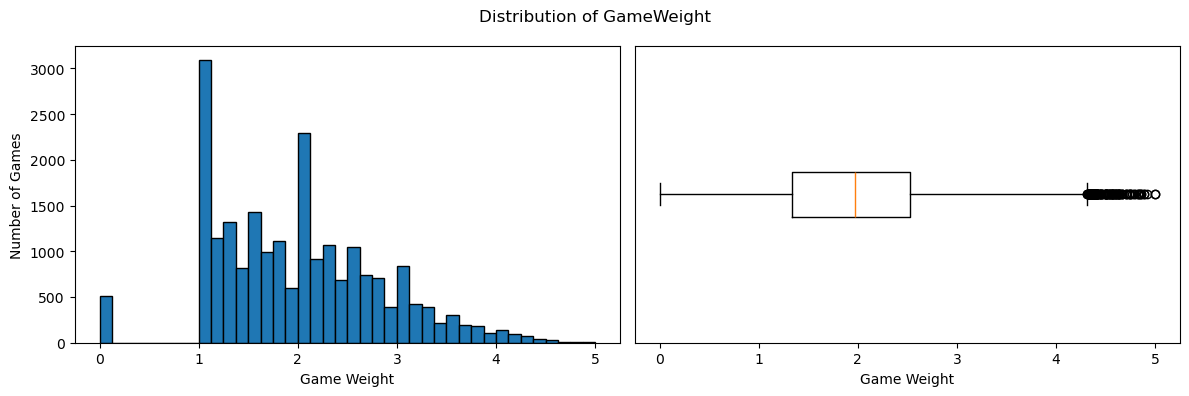

In [65]:
data = df['GameWeight'].dropna()

print(f'Mean: {data.mean():.2f}')
print(f'Std:  {data.std():.2f}')
print(f'Skew: {data.skew():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribution of GameWeight')
axes[0].hist(data, bins=40, edgecolor='black')
axes[0].set_xlabel('Game Weight')
axes[0].set_ylabel('Number of Games')
axes[1].boxplot(data, vert=False)
axes[1].set_xlabel('Game Weight')
axes[1].set_yticks([])
plt.tight_layout()
plt.show()
plt.close()

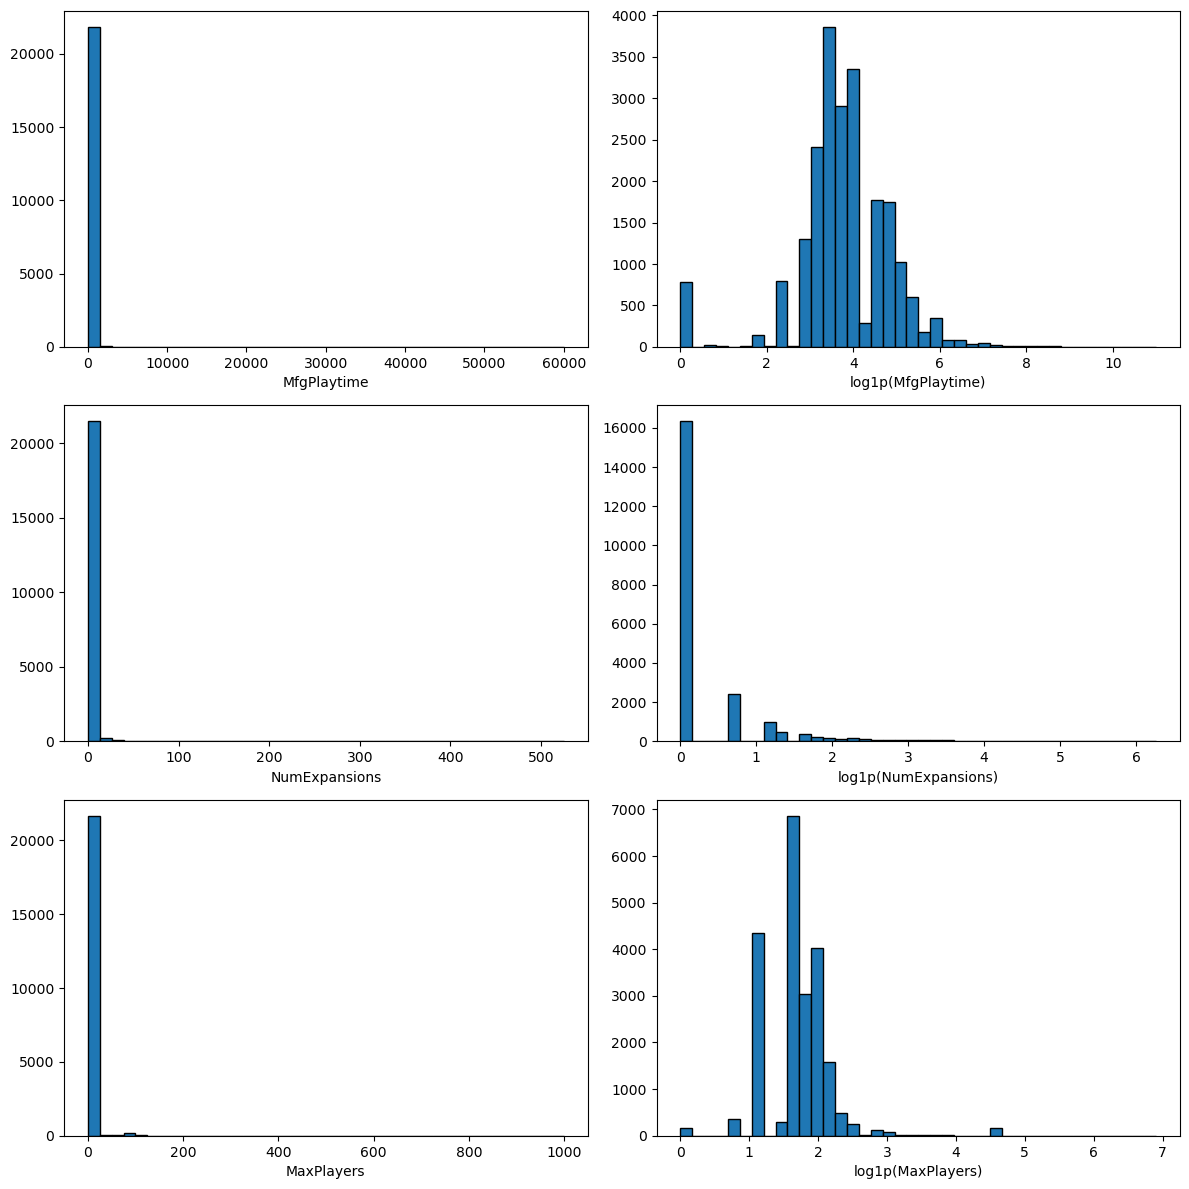

In [80]:
# numeric features disribution
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

data = df['MfgPlaytime'].dropna()
data_log = np.log1p(data)
axes[0, 0].hist(data, bins=40, edgecolor='black')
axes[0, 0].set_xlabel('MfgPlaytime')
axes[0, 1].hist(data_log, bins=40, edgecolor='black')
axes[0, 1].set_xlabel('log1p(MfgPlaytime)')

data = df['NumExpansions'].dropna()
data_log = np.log1p(data)
axes[1, 0].hist(data, bins=40, edgecolor='black')
axes[1, 0].set_xlabel('NumExpansions')
axes[1, 1].hist(data_log, bins=40, edgecolor='black')
axes[1, 1].set_xlabel('log1p(NumExpansions)')

data = df['MaxPlayers'].dropna()
data_log = np.log1p(data)
axes[2, 0].hist(data, bins=40, edgecolor='black')
axes[2, 0].set_xlabel('MaxPlayers')
axes[2, 1].hist(data_log, bins=40, edgecolor='black')
axes[2, 1].set_xlabel('log1p(MaxPlayers)')

plt.tight_layout()
plt.show()
plt.close()

In [84]:
corrs = df[NUMERIC_FEATURES].corr()[['AvgRating']].drop('AvgRating')
corrs = corrs.sort_values('AvgRating', ascending=False)

print('Correlation with AvgRating:')
display(corrs.round(3))


Correlation with AvgRating:


,AvgRating
GameWeight,0.478
NumWant,0.328
NumOwned,0.178
NumExpansions,0.154
MfgPlaytime,0.093
YearPublished,0.079
MaxPlayers,-0.041
MinPlayers,-0.173
NumComments,NaN


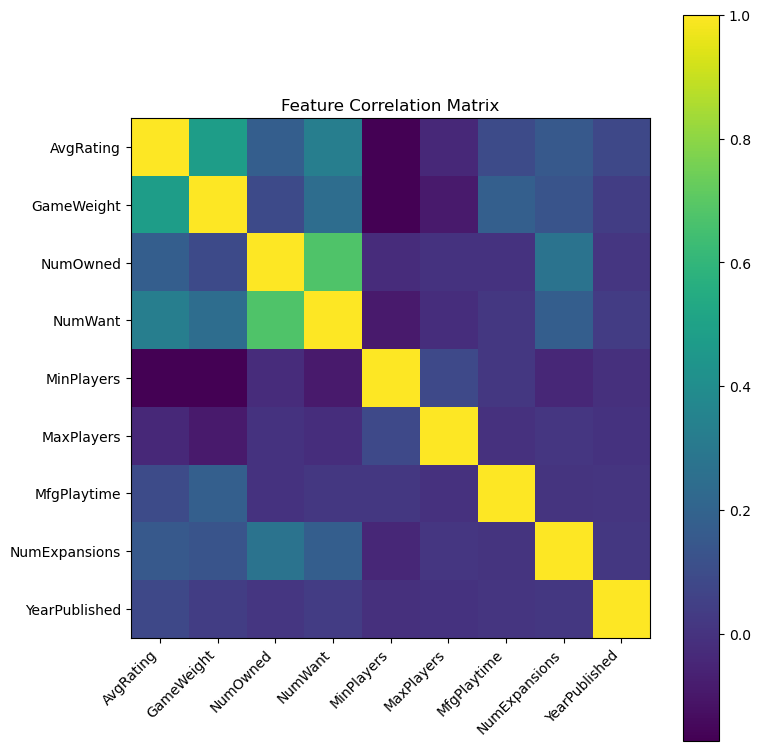

In [104]:
# correlation
corr = df[NUMERIC_FEATURES].corr()

fig, axes = plt.subplots(figsize=(8,8))
im = axes.imshow(corr)
plt.colorbar(im, ax=axes)

axes.set_xticks(range(len(corr.columns)))
axes.set_yticks(range(len(corr.columns)))
axes.set_xticklabels(corr.columns, rotation=45, ha='right')
axes.set_yticklabels(corr.columns)

axes.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()
plt.close()

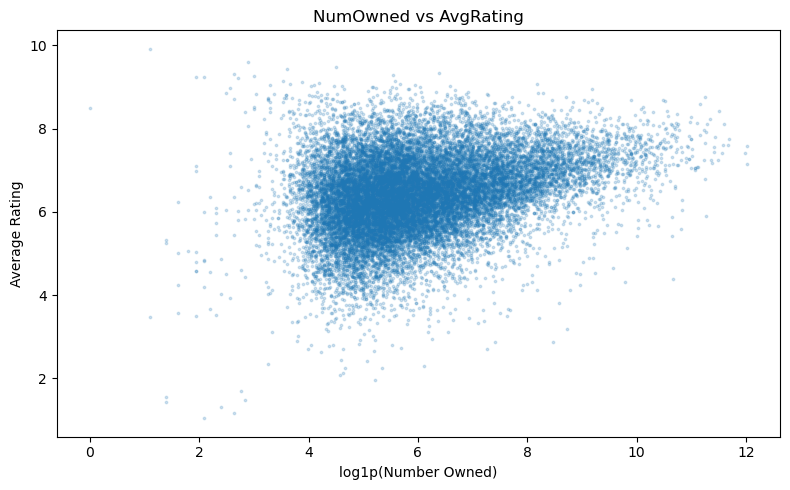

Correlation (log NumOwned vs AvgRating): 0.296


In [110]:
plot_df = df[['NumOwned', 'AvgRating']].dropna()
x = np.log1p(plot_df['NumOwned'])
y = plot_df['AvgRating']

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.2, s=3)
plt.title('NumOwned vs AvgRating')
plt.xlabel('log1p(Number Owned)')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()
plt.close()

print(f'Correlation (log NumOwned vs AvgRating): {np.corrcoef(x, y)[0, 1]:.3f}')